Data Prepare

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/student-mat.csv', sep=';')


cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


X = df.drop(columns=['G3'])   
y = df['G3']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (316, 32)
Test size: (79, 32)


Models Train

In [2]:
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost":           XGBRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results[name] = {"RMSE": round(rmse, 3), "R2": round(r2, 3)}
    print(f"{name:20s} → RMSE: {rmse:.3f}  |  R²: {r2:.3f}")

Linear Regression    → RMSE: 2.243  |  R²: 0.755
Random Forest        → RMSE: 1.867  |  R²: 0.830
XGBoost              → RMSE: 2.220  |  R²: 0.760


 Best Model Save

In [4]:
import pickle


best_model = models["Random Forest"]

with open('../model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model saved as model.pkl ")

Model saved as model.pkl 


 Feature Importance

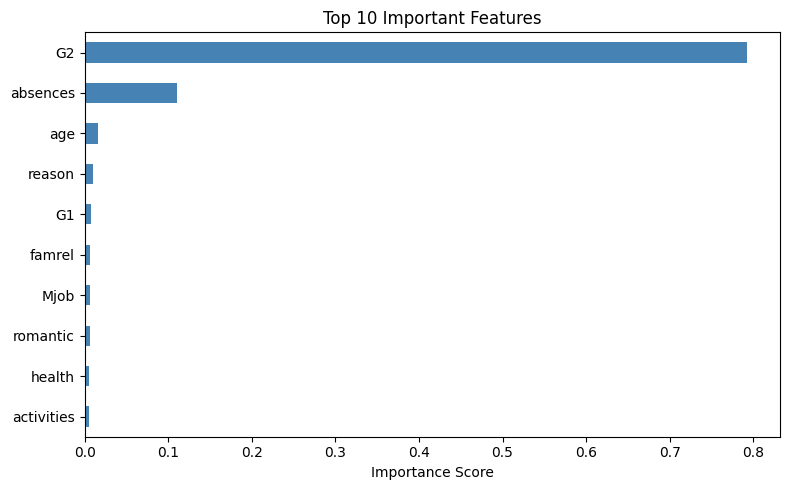

In [5]:
import matplotlib.pyplot as plt
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Top 10 Important Features')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()